In [ ]:
# ============================================================
# PFE Baseline: ResNet-50 on HAM10000 (PyTorch)
# Dataset: HAM10000 Skin Lesion Classification
# Architecture: Standard ResNet-50 (224x224 input)
# Ready for: Pruning, Quantization, Distillation, LoRA
# ============================================================
#
# EXPECTED DATA STRUCTURE:
#   ./ham10000/
#       HAM10000_metadata.csv          <- official metadata CSV
#       images/                        <- all .jpg images (both parts merged)
#           ISIC_0024306.jpg
#           ISIC_0024307.jpg
#           ...
#
# Download from: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000?resource=download
# Merge HAM10000_images_part1/ and HAM10000_images_part2/ into images/
# ============================================================

In [14]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
import time, os, json, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, precision_score,
                             recall_score, f1_score)
from thop import profile

In [15]:
# -- REPRODUCIBILITY ------------------------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

In [16]:
# -- CONFIG ---------------------------------------------------
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE  = 64
NUM_CLASSES = 7
IMG_SIZE    = 224
VAL_SPLIT   = 0.2
SAVE_PATH   = "__ham10000__baseline_resnet50.pth"

EPOCHS      = 50
LR          = 0.01
PATIENCE    = 10   # early stopping

DATA_ROOT   = "./ham10000"
CSV_PATH    = os.path.join(DATA_ROOT, "HAM10000_metadata.csv")
IMG_DIR     = os.path.join(DATA_ROOT, "images")

HAM10000_CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

HAM10000_CLASS_NAMES = {
    "akiec": "Actinic Keratoses",
    "bcc":   "Basal Cell Carcinoma",
    "bkl":   "Benign Keratosis",
    "df":    "Dermatofibroma",
    "mel":   "Melanoma",
    "nv":    "Melanocytic Nevi",
    "vasc":  "Vascular Lesions",
}

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

print(f"Using device : {DEVICE}")
print(f"Training     : up to {EPOCHS} epochs, early stopping patience={PATIENCE}")

Using device : cuda
Training     : up to 50 epochs, early stopping patience=10


In [17]:
# -- DATASET --------------------------------------------------
class HAM10000Dataset(Dataset):
    def __init__(self, df, img_dir, transform=None, class_list=HAM10000_CLASSES):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform
        self.class2idx = {cls: i for i, cls in enumerate(class_list)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"] + ".jpg")
        image    = Image.open(img_path).convert("RGB")
        label    = self.class2idx[row["dx"]]
        if self.transform:
            image = self.transform(image)
        return image, label

In [18]:
# -- MODEL ----------------------------------------------------
def build_model(num_classes=NUM_CLASSES):
    weights = models.ResNet50_Weights.IMAGENET1K_V1
    model   = models.resnet50(weights=weights)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

model = build_model(NUM_CLASSES).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 23,522,375


In [19]:
# -- DATA LOADING & SPLIT -------------------------------------
df = pd.read_csv(CSV_PATH)
df = df[["image_id", "dx"]].drop_duplicates(subset="image_id").reset_index(drop=True)

print(f"\nDataset size: {len(df)} images")
print("\nClass distribution:")
class_counts = df["dx"].value_counts()
for cls in HAM10000_CLASSES:
    count = class_counts.get(cls, 0)
    pct   = count / len(df) * 100
    print(f"  {cls:<8} ({HAM10000_CLASS_NAMES[cls]:<25}): {count:>5} ({pct:.1f}%)")

train_df, val_df = train_test_split(
    df, test_size=VAL_SPLIT, random_state=SEED, stratify=df["dx"]
)
print(f"\nTrain: {len(train_df)} | Val: {len(val_df)}")


Dataset size: 10015 images

Class distribution:
  akiec    (Actinic Keratoses        ):   327 (3.3%)
  bcc      (Basal Cell Carcinoma     ):   514 (5.1%)
  bkl      (Benign Keratosis         ):  1099 (11.0%)
  df       (Dermatofibroma           ):   115 (1.1%)
  mel      (Melanoma                 ):  1113 (11.1%)
  nv       (Melanocytic Nevi         ):  6705 (66.9%)
  vasc     (Vascular Lesions         ):   142 (1.4%)

Train: 8012 | Val: 2003


In [20]:
# -- TRANSFORMS -----------------------------------------------
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [21]:
# -- WEIGHTED SAMPLER (class imbalance) -----------------------
# Use sampler ONLY — no weighted loss on top (avoids double correction)
class2idx      = {cls: i for i, cls in enumerate(HAM10000_CLASSES)}
train_labels   = train_df["dx"].map(class2idx).values
class_counts_  = np.bincount(train_labels, minlength=NUM_CLASSES)
class_weights  = 1.0 / (class_counts_ + 1e-6)
sample_weights = class_weights[train_labels]

sampler = WeightedRandomSampler(
    weights     = torch.from_numpy(sample_weights).float(),
    num_samples = len(train_labels),
    replacement = True,
    generator   = g,
)

In [22]:
# -- DATALOADERS ----------------------------------------------
train_set = HAM10000Dataset(train_df, IMG_DIR, transform=transform_train)
val_set   = HAM10000Dataset(val_df,   IMG_DIR, transform=transform_val)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE,
                          sampler=sampler,
                          num_workers=0,
                          worker_init_fn=seed_worker,
                          generator=g)

val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE,
                          shuffle=False,
                          num_workers=0,
                          worker_init_fn=seed_worker)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 126 | Val batches: 32


In [23]:
# -- LOSS & OPTIMIZER -----------------------------------------
# No weight= here — sampler already handles class imbalance
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.SGD(
    model.parameters(), lr=LR, momentum=0.9, weight_decay=1e-4
)

# ReduceLROnPlateau adapts to actual val performance
# much better than CosineAnnealingLR for imbalanced medical datasets
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=5, min_lr=1e-5
)

In [24]:
# -- TRAINING HELPERS -----------------------------------------
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        correct    += outputs.argmax(1).eq(labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            correct += model(inputs).argmax(1).eq(labels).sum().item()
            total   += labels.size(0)
    return correct / total

In [25]:
# -- TRAINING LOOP --------------------------------------------
best_val_acc                     = 0.0
no_improve                       = 0
train_accs, val_accs, train_losses = [], [], []

print("\n" + "="*55)
print("TRAINING")
print("="*55)

for epoch in range(EPOCHS):
    loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_acc         = evaluate(model, val_loader)
    scheduler.step(val_acc)   # pass val_acc — scheduler decides when to drop LR

    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_losses.append(loss)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        no_improve = 0
        marker = " <- best saved"
    else:
        no_improve += 1
        marker = f" (no improve {no_improve}/{PATIENCE})"

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | Loss: {loss:.4f} | "
          f"Train: {train_acc:.4f} | Val: {val_acc:.4f}{marker}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}")
        break

print(f"\nBest validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")


TRAINING
Epoch  1/50 | Loss: 1.3082 | Train: 0.5864 | Val: 0.6925 <- best saved
Epoch  2/50 | Loss: 0.9596 | Train: 0.7607 | Val: 0.7224 <- best saved
Epoch  3/50 | Loss: 0.8641 | Train: 0.8104 | Val: 0.7559 <- best saved
Epoch  4/50 | Loss: 0.8023 | Train: 0.8412 | Val: 0.7334 (no improve 1/10)
Epoch  5/50 | Loss: 0.7543 | Train: 0.8667 | Val: 0.7654 <- best saved
Epoch  6/50 | Loss: 0.7169 | Train: 0.8848 | Val: 0.8038 <- best saved
Epoch  7/50 | Loss: 0.6998 | Train: 0.8904 | Val: 0.7883 (no improve 1/10)
Epoch  8/50 | Loss: 0.6742 | Train: 0.9020 | Val: 0.8163 <- best saved
Epoch  9/50 | Loss: 0.6649 | Train: 0.9053 | Val: 0.8288 <- best saved
Epoch 10/50 | Loss: 0.6545 | Train: 0.9130 | Val: 0.7978 (no improve 1/10)
Epoch 11/50 | Loss: 0.6413 | Train: 0.9211 | Val: 0.8457 <- best saved
Epoch 12/50 | Loss: 0.6130 | Train: 0.9325 | Val: 0.8537 <- best saved
Epoch 13/50 | Loss: 0.6098 | Train: 0.9353 | Val: 0.8023 (no improve 1/10)
Epoch 14/50 | Loss: 0.5942 | Train: 0.9448 | Val: 0

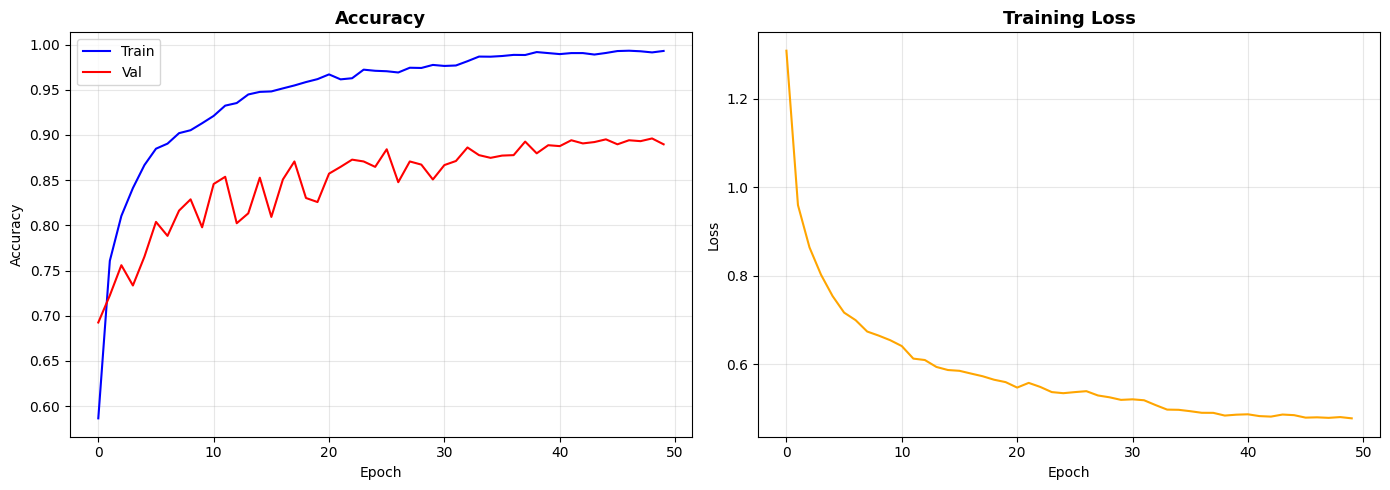

In [26]:
# -- TRAINING CURVES ------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_accs, label="Train", color="blue")
ax1.plot(val_accs,   label="Val",   color="red")
ax1.set_title("Accuracy", fontsize=13, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(train_losses, color="orange")
ax2.set_title("Training Loss", fontsize=13, fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("__ham10000__training_curves.png", dpi=150)
plt.show()

In [27]:
# -- FULL EVALUATION ------------------------------------------
print("\n" + "="*55)
print("FULL EVALUATION")
print("="*55)

# Fresh model instance — avoids thop buffer contamination
model = build_model(NUM_CLASSES).to(DEVICE)
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(DEVICE)
        preds  = model(inputs).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc       = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="macro")
recall    = recall_score(all_labels, all_preds, average="macro")
f1        = f1_score(all_labels, all_preds, average="macro")

print(f"\n  Accuracy          : {acc:.4f}  ({acc*100:.2f}%)")
print(f"  Precision (macro) : {precision:.4f}")
print(f"  Recall    (macro) : {recall:.4f}")
print(f"  F1-score  (macro) : {f1:.4f}")
print("\nPer-class report:")
print(classification_report(all_labels, all_preds,
                             target_names=HAM10000_CLASSES, digits=4))


FULL EVALUATION

  Accuracy          : 0.8962  (89.62%)
  Precision (macro) : 0.8398
  Recall    (macro) : 0.8381
  F1-score  (macro) : 0.8370

Per-class report:
              precision    recall  f1-score   support

       akiec     0.6957    0.7385    0.7164        65
         bcc     0.7619    0.9320    0.8384       103
         bkl     0.8636    0.7773    0.8182       220
          df     0.9048    0.8261    0.8636        23
         mel     0.7430    0.7130    0.7277       223
          nv     0.9466    0.9515    0.9491      1341
        vasc     0.9630    0.9286    0.9455        28

    accuracy                         0.8962      2003
   macro avg     0.8398    0.8381    0.8370      2003
weighted avg     0.8969    0.8962    0.8958      2003



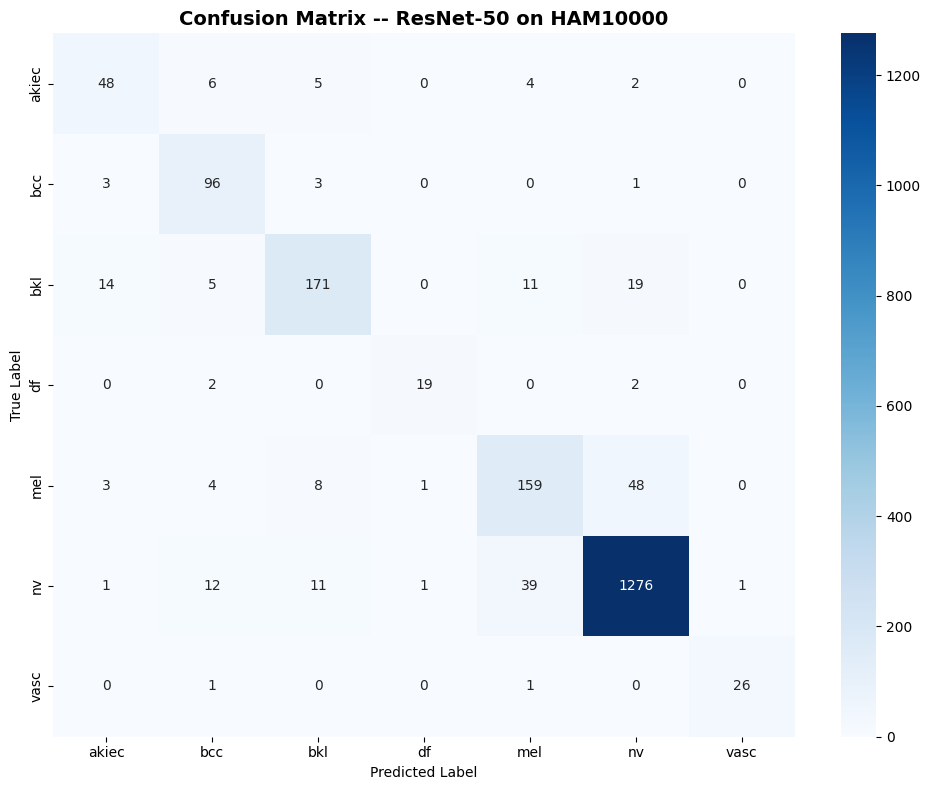

In [28]:
# -- CONFUSION MATRIX -----------------------------------------
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=HAM10000_CLASSES, yticklabels=HAM10000_CLASSES)
plt.title("Confusion Matrix -- ResNet-50 on HAM10000", fontsize=14, fontweight="bold")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("__ham10000__confusion_matrix.png", dpi=150)
plt.show()

In [29]:
# -- MODEL COMPLEXITY METRICS ---------------------------------
print("\n" + "="*55)
print("MODEL COMPLEXITY METRICS")
print("="*55)

size_mb = os.path.getsize(SAVE_PATH) / 1e6

# Separate instance for thop — keeps main model's state_dict clean
_model_for_flops = build_model(NUM_CLASSES).to(DEVICE)
_model_for_flops.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
_model_for_flops.eval()
dummy   = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
macs, _ = profile(_model_for_flops, inputs=(dummy,), verbose=False)
flops_G = macs * 2 / 1e9
del _model_for_flops

print(f"  Parameters      : {total_params:,}")
print(f"  Model size      : {size_mb:.2f} MB")
print(f"  FLOPs           : {flops_G:.3f} GFLOPs")

# -- INFERENCE TIME: CPU --------------------------------------
print("\n  Measuring CPU inference times ...")
model_cpu = build_model(NUM_CLASSES)
model_cpu.load_state_dict(torch.load(SAVE_PATH, map_location="cpu"))
model_cpu = model_cpu.eval()

dummy_single_cpu = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
dummy_batch_cpu  = torch.randn(128, 3, IMG_SIZE, IMG_SIZE)

with torch.no_grad():
    for _ in range(10):
        model_cpu(dummy_single_cpu)

times_cpu_single = []
with torch.no_grad():
    for _ in range(100):
        t0 = time.perf_counter()
        model_cpu(dummy_single_cpu)
        times_cpu_single.append(time.perf_counter() - t0)
inf_ms_single_cpu = np.mean(times_cpu_single) * 1000

with torch.no_grad():
    for _ in range(5):
        model_cpu(dummy_batch_cpu)

times_cpu_batch = []
with torch.no_grad():
    for _ in range(20):
        t0 = time.perf_counter()
        model_cpu(dummy_batch_cpu)
        times_cpu_batch.append(time.perf_counter() - t0)
inf_ms_batch128_cpu     = np.mean(times_cpu_batch) * 1000
inf_ms_per_img_cpu      = inf_ms_batch128_cpu / 128
throughput_imgs_sec_cpu = 128 / (inf_ms_batch128_cpu / 1000)

del model_cpu, dummy_single_cpu, dummy_batch_cpu
print("  CPU timing done")

# -- INFERENCE TIME: GPU --------------------------------------
print("  Measuring GPU inference times ...")
dummy_single_gpu = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)

with torch.no_grad():
    for _ in range(50):
        model(dummy_single_gpu)
torch.cuda.synchronize()

times_gpu_single = []
with torch.no_grad():
    for _ in range(500):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        model(dummy_single_gpu)
        torch.cuda.synchronize()
        times_gpu_single.append(time.perf_counter() - t0)
inf_ms_single_gpu = np.mean(times_gpu_single) * 1000

dummy_batch_gpu = torch.randn(128, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
start_ev        = torch.cuda.Event(enable_timing=True)
end_ev          = torch.cuda.Event(enable_timing=True)

with torch.no_grad():
    for _ in range(10):
        model(dummy_batch_gpu)
torch.cuda.synchronize()

batch_times_gpu = []
with torch.no_grad():
    for _ in range(100):
        start_ev.record()
        model(dummy_batch_gpu)
        end_ev.record()
        torch.cuda.synchronize()
        batch_times_gpu.append(start_ev.elapsed_time(end_ev))
inf_ms_batch128_gpu     = np.mean(batch_times_gpu)
inf_ms_per_img_gpu      = inf_ms_batch128_gpu / 128
throughput_imgs_sec_gpu = 128 / (inf_ms_batch128_gpu / 1000)
print("  GPU timing done")

# -- PRINT FULL RESULTS ---------------------------------------
print(f"\n{'='*55}")
print("BASELINE METRICS SUMMARY")
print(f"{'='*55}")
print(f"  Accuracy          : {acc:.4f}")
print(f"  Precision (macro) : {precision:.4f}")
print(f"  Recall    (macro) : {recall:.4f}")
print(f"  F1-score  (macro) : {f1:.4f}")
print(f"  Parameters        : {total_params:,}")
print(f"  Model size        : {size_mb:.2f} MB")
print(f"  FLOPs             : {flops_G:.3f} GFLOPs")
print(f"  --- Inference (CPU) ---")
print(f"  Single image      : {inf_ms_single_cpu:.3f} ms")
print(f"  Batch-128         : {inf_ms_batch128_cpu:.2f} ms")
print(f"  Per-image         : {inf_ms_per_img_cpu:.3f} ms")
print(f"  Throughput        : {throughput_imgs_sec_cpu:.1f} imgs/sec")
print(f"  --- Inference (GPU) ---")
print(f"  Single image      : {inf_ms_single_gpu:.3f} ms  (synchronized)")
print(f"  Batch-128         : {inf_ms_batch128_gpu:.2f} ms  (CUDA events)")
print(f"  Per-image         : {inf_ms_per_img_gpu:.3f} ms")
print(f"  Throughput        : {throughput_imgs_sec_gpu:.1f} imgs/sec")


MODEL COMPLEXITY METRICS
  Parameters      : 23,522,375
  Model size      : 94.41 MB
  FLOPs           : 8.263 GFLOPs

  Measuring CPU inference times ...
  CPU timing done
  Measuring GPU inference times ...
  GPU timing done

BASELINE METRICS SUMMARY
  Accuracy          : 0.8962
  Precision (macro) : 0.8398
  Recall    (macro) : 0.8381
  F1-score  (macro) : 0.8370
  Parameters        : 23,522,375
  Model size        : 94.41 MB
  FLOPs             : 8.263 GFLOPs
  --- Inference (CPU) ---
  Single image      : 31.938 ms
  Batch-128         : 2668.42 ms
  Per-image         : 20.847 ms
  Throughput        : 48.0 imgs/sec
  --- Inference (GPU) ---
  Single image      : 5.200 ms  (synchronized)
  Batch-128         : 3967.90 ms  (CUDA events)
  Per-image         : 30.999 ms
  Throughput        : 32.3 imgs/sec


In [30]:
# -- SAVE METRICS JSON ----------------------------------------
baseline_metrics = {
    "accuracy"  : acc,
    "precision" : precision,
    "recall"    : recall,
    "f1"        : f1,
    "params"    : total_params,
    "size_mb"   : size_mb,
    "flops_G"   : flops_G,
    "inference_ms": {
        "cpu": {
            "single_img_ms"      : round(inf_ms_single_cpu, 4),
            "batch128_ms"        : round(inf_ms_batch128_cpu, 4),
            "per_img_ms"         : round(inf_ms_per_img_cpu, 4),
            "throughput_imgs_sec": round(throughput_imgs_sec_cpu, 1),
            "timing_method"      : "time.perf_counter()",
        },
        "gpu": {
            "single_img_ms"      : round(inf_ms_single_gpu, 4),
            "batch128_ms"        : round(inf_ms_batch128_gpu, 4),
            "per_img_ms"         : round(inf_ms_per_img_gpu, 4),
            "throughput_imgs_sec": round(throughput_imgs_sec_gpu, 1),
            "timing_method"      : "CUDA events + torch.cuda.synchronize()",
        },
    },
}
with open("__ham10000__baseline_metrics.json", "w") as f:
    json.dump(baseline_metrics, f, indent=2)
print("\n Metrics saved -> __ham10000__baseline_metrics.json")


 Metrics saved -> __ham10000__baseline_metrics.json


In [31]:
# -- PREDICT ON CUSTOM IMAGES ---------------------------------
predict_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def predict_image(image_path, model, show=True):
    img    = Image.open(image_path).convert("RGB")
    tensor = predict_transform(img).unsqueeze(0).to(DEVICE)

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).squeeze().cpu().numpy()

    pred_idx   = probs.argmax()
    pred_class = HAM10000_CLASSES[pred_idx]
    pred_name  = HAM10000_CLASS_NAMES[pred_class]
    confidence = probs[pred_idx]

    if show:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        ax1.imshow(img)
        ax1.set_title(f"Prediction: {pred_name}\nConfidence: {confidence:.2%}",
                      fontsize=12, fontweight="bold")
        ax1.axis("off")
        colors = ["crimson" if i == pred_idx else "steelblue" for i in range(NUM_CLASSES)]
        ax2.barh(HAM10000_CLASSES, probs, color=colors)
        ax2.set_xlabel("Probability")
        ax2.set_title("Class Probabilities")
        ax2.set_xlim(0, 1)
        for i, v in enumerate(probs):
            ax2.text(v + 0.01, i, f"{v:.1%}", va="center", fontsize=9)
        plt.tight_layout()
        plt.savefig(f"pred_{os.path.splitext(os.path.basename(image_path))[0]}.png", dpi=150)
        plt.show()

    top3 = sorted(zip(HAM10000_CLASSES, probs), key=lambda x: -x[1])[:3]
    print(f"  File      : {os.path.basename(image_path)}")
    print(f"  Predicted : {pred_class} -- {pred_name} ({confidence:.2%})")
    print(f"  Top-3     : {[(c, f'{p:.2%}') for c, p in top3]}\n")
    return pred_class, probs


def predict_folder(folder_path, model, save_json=True):
    supported = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    files = [f for f in os.listdir(folder_path) if f.lower().endswith(supported)]
    if not files:
        print(f"No images found in {folder_path}")
        return
    print(f"\n{'File':<35} {'Prediction':<10} {'Full Name':<28} {'Confidence':>10}")
    print("-" * 87)
    results = []
    for fname in sorted(files):
        pred_class, probs = predict_image(os.path.join(folder_path, fname),
                                          model, show=False)
        conf      = float(probs.max())
        pred_name = HAM10000_CLASS_NAMES[pred_class]
        results.append({"file": fname, "prediction": pred_class,
                        "full_name": pred_name, "confidence": conf})
        print(f"  {fname:<33} {pred_class:<10} {pred_name:<28} {conf:>9.2%}")
        print("-" * 87)

    if save_json:
        with open("__ham10000__output_on_test_data.json", "w") as f:
            json.dump(results, f, indent=4)
        print(f"\n Predictions saved to __ham10000__output_on_test_data.json")

    return results


# -- USAGE ----------------------------------------------------
# predict_image("./test_images/lesion.jpg", model)
# predict_folder("./data_test/", model)

In [32]:
# -- SAVE FULL CHECKPOINT -------------------------------------
config_dict = {
    "model_name" : "resnet50_ham10000",
    "num_classes": NUM_CLASSES,
    "input_size" : [3, IMG_SIZE, IMG_SIZE],
    "normalization": {"mean": IMAGENET_MEAN, "std": IMAGENET_STD},
    "training": {
        "batch_size"  : BATCH_SIZE,
        "epochs"      : EPOCHS,
        "lr"          : LR,
        "optimizer"   : "SGD momentum=0.9 weight_decay=1e-4",
        "scheduler"   : "ReduceLROnPlateau factor=0.5 patience=5",
        "early_stop"  : PATIENCE,
        "val_split"   : VAL_SPLIT,
        "imbalance"   : "WeightedRandomSampler only (no weighted loss)",
    }
}

torch.save({
    "model_state_dict": model.state_dict(),
    "config"          : config_dict,
    "classes"         : HAM10000_CLASSES,
    "class_names"     : HAM10000_CLASS_NAMES,
}, "__ham10000__model_checkpoint.pth")

print("\n" + "="*55)
print("BASELINE COMPLETE -- ready for compression experiments")
print("="*55)
print(f"  Weights  -> {SAVE_PATH}")
print(f"  Metrics  -> __ham10000__baseline_metrics.json")
print(f"  Plots    -> __ham10000__training_curves.png, __ham10000__confusion_matrix.png")
print(f"  Output   -> __ham10000__output_on_test_data.json")


BASELINE COMPLETE -- ready for compression experiments
  Weights  -> __ham10000__baseline_resnet50.pth
  Metrics  -> __ham10000__baseline_metrics.json
  Plots    -> __ham10000__training_curves.png, __ham10000__confusion_matrix.png
  Output   -> __ham10000__output_on_test_data.json


In [33]:
# -- TO RELOAD THE MODEL --------------------------------------
# checkpoint = torch.load("__ham10000__model_checkpoint.pth", map_location="cpu")
# config     = checkpoint["config"]
# classes    = checkpoint["classes"]
# model      = build_model(config["num_classes"])
# model.load_state_dict(checkpoint["model_state_dict"])
# model.eval()